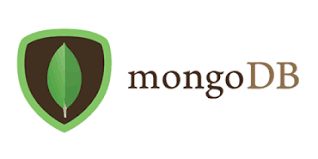   

# MongoDB — TP CRUD :  À vous de jouer avec les données !

## Introduction

Après avoir découvert le modèle documentaire MongoDB, il est temps de manipuler réellement les données.

Dans ce TP, vous allez travailler sur une collection movies et utiliser MQL (MongoDB Query Language) pour rechercher, ajouter, modifier et supprimer des documents.

L’objectif n’est pas seulement d’apprendre une syntaxe : vous devrez surtout observer la structure des documents et choisir la bonne manière de les interroger.

:::{important} Objectifs pédagogiques et compétences visées

À la fin de ce TP, vous serez capables de :

* Rechercher des documents avec find() et findOne()
* Construire des filtres et des projections
* Utiliser les opérateurs de comparaison et logiques : $gt, $gte, $in, $and, $or, $nor…
* Interroger des documents imbriqués avec la notation pointée
* Interroger des tableaux et tableaux de documents
* Comprendre quand et pourquoi utiliser $elemMatch
* Trier et limiter les résultats avec sort(), skip() et limit()
* Insérer des documents avec insertOne() et insertMany()
* Modifier des documents avec $set, $unset, $push…
* Supprimer des documents avec deleteOne() et deleteMany()
* Comprendre les quatre opérations fondamentales du CRUD : Create, Read, Update, Delete

:::

### Un conseil avant de commencer

MongoDB est très flexible, mais cette flexibilité demande de bien comprendre la structure des données que vous manipulez.

Avant chaque requête, posez-vous donc trois questions :
* Quelle est la structure du document ?
* Quelles données est-ce que je cherche ?
* Quel opérateur MongoDB est le plus adapté ?

Et surtout : testez, observez les résultats et expérimentez ! C’est le meilleur moyen de comprendre MQL.



# 1. Préparer l'environnement

Depuis la racine du dépôt, placez-vous dans `docker`. Démarrez le service et vérifiez son état :

:::bash
cd docker
docker compose up -d mongosingle
docker compose ps mongosingle
:::

Chargez uniquement la collection nécessaire à ce TP. **Cette commande réinitialise `training.movies`** : le service d'import utilise `--drop`. Elle permet aussi de recommencer le TP depuis son état initial.

:::bash
docker compose run --rm loaddatamoviesintomongosingle
:::

Ouvrez ensuite le shell sur la base `training`. Le fichier Compose utilise `mongo:4.4.6`, qui fournit le shell historique `mongo`.

:::bash
docker compose exec mongosingle mongo training
:::

Vérifiez le résultat de la commande :

:::bash
2026-09-24T19:09:02.114+0000	88 document(s) imported successfully. 0 document(s) failed to import.
:::

Le fichier `docker/mongo/mongodb/movies.json` contient **88 documents**. 

Pour ce TP, les commandes seront à executer dans votre client NoSQLBooster.

# 2. Rechercher des documents (Read)

MongoDB utilise le langage de requête MQL (Mongo Query Language). L'expression de la condition, de la projection et des documents s'écrivent sous forme d'objets JavaScript.

La condition de recherche, appelée filtre, est exprimée sous la forme d’un document, tout comme la projection.

Dans l’exemple suivant :

:::
db.movies.find(
    { title: "Vertigo" },
    { title: 1 }
)
:::

MongoDB recherche tous les documents de la collection **movies** dont le champ title a pour valeur "Vertigo".

La projection `{ title: 1 }` indique que seul le champ title doit être retourné pour chaque document. Le champ _id est toutefois affiché par défaut.

Pour le masquer, il suffit de préciser _id: 0 :

:::
db.movies.find(
    { title: "Vertigo" },
    { title: 1, _id: 0 }
)
:::


## 2.1 Exemples guidés

Afficher un premier document pour avoir une idée de la structure de nos documents :

:::javascript
db.movies.find({}).limit(1).pretty()
:::

Rechercher le film « Vertigo » :

:::javascript
db.movies.find({ title: "Vertigo" }).pretty()
:::

Afficher uniquement les titres des films où joue un acteur nommé Stewart :

:::javascript
db.movies.find({ "actors.last_name": "Stewart" }, { _id: 0, title: 1 })
:::

Afficher les titres et réalisateurs de « Gladiator » ou « Spider-Man » :

:::javascript
db.movies.find(
  { $or: [{ title: "Gladiator" }, { title: "Spider-Man" }] },
  { _id: 0, title: 1, "director.first_name": 1, "director.last_name": 1 }
)
:::

## 2.2 Exercices

#### Afficher uniquement les titres de tous les films

:::{admonition} Solution!
:class: dropdown
```
db.movies.find({}, { _id: 0, title: 1 })
```
:::

### Afficher uniquement le résumé de « Spider-Man »

:::{admonition} Solution!
:class: dropdown
```
db.movies.find({ title: "Spider-Man" }, { _id: 0, summary: 1 })
```
:::

### Afficher les titres des films sans champ `director`

:::{hint} Indice 
:class: dropdown
Regarder l'opérateur $exists : https://www.mongodb.com/docs/manual/reference/operator/query/exists/
:::

:::{admonition} Solution!
:class: dropdown
```
db.movies.find({ director: { $exists: false } }, { _id: 0, title: 1 })
```
`$exists: false` recherche un champ absent. Un champ présent avec la valeur `null` ne satisfait pas ce filtre. Un résultat vide est possible et ne signifie pas que la requête est incorrecte.
:::

### Afficher les titres des films produits de 1995 à 2000, bornes incluses

:::{admonition} Solution!
:class: dropdown
```
db.movies.find({ year: { $gte: 1995, $lte: 2000 } }, { _id: 0, title: 1 })
```
:::

### Afficher les titres et les noms complets des acteurs des films réalisés par Spielberg ou Cameron

:::{hint} Indice 
:class: dropdown

Regarder l'opérateur 

$in : https://www.mongodb.com/docs/manual/reference/operator/query/in/

ou
$or : https://www.mongodb.com/docs/manual/reference/operator/query/or/

:::

:::{admonition} Solution!
:class: dropdown

```
db.movies.find(
  { "director.last_name": { $in: ["Spielberg", "Cameron"] } },
  { _id: 0, title: 1, "actors.first_name": 1, "actors.last_name": 1 }
)
```

:::

### Afficher les titres et genres des films qui ne sont ni des drames ni des comédies

:::{hint} Indice 
:class: dropdown
Regarder l'opérateur $nin : https://www.mongodb.com/docs/manual/reference/operator/query/nin/
:::

:::{admonition} Solution!
:class: dropdown
```
db.movies.find(
  { genre: { $exists: true, $nin: ["drama", "Comédie"] } },
  { _id: 0, title: 1, genre: 1 }
)
```
:::

### Afficher les titres des films où Clint Eastwood est acteur, mais dont le réalisateur porte un autre nom

:::{hint} Indice 
:class: dropdown

Regarder $elemMatch : https://www.mongodb.com/docs/manual/reference/operator/query/elemMatch/

:::

:::{admonition} Solution
:class: dropdown

```
db.movies.find(
  {
    "actors.first_name": "Clint", "actors.last_name": "Eastwood" } },
    $nor: [
      {
        "director.first_name": "Clint",
        "director.last_name": "Eastwood"
      }
    ]
  },
  { _id: 0, title: 1 }
)
```
Pourquoi $elemMatch est important pour actors ?

Pour le film "movie:4", nous avons :
```
actors: [
  {
    _id: "artist:11",
    first_name: "Clint",
    last_name: "Travolta",
    birth_date: "1954",
    role: "Sean Archer/Castor Troy"
  },
  {
    _id: "artist:12",
    first_name: "Steve",
    last_name: "Eastwood",
    birth_date: "1954",
    role: "Sean Archer/Castor Troy"
  }
]
```
Ce document ne devrait pas correspondre à une recherche de l’acteur Clint Eastwood, puisqu’aucun élément du tableau ne contient à la fois first_name: "Clint" et last_name: "Eastwood".

Pourtant, si nous écrivons :
```
{
  "actors.first_name": "Clint",
  "actors.last_name": "Eastwood"
}
```

MongoDB évalue séparément les deux conditions sur le tableau actors :
* il trouve first_name: "Clint" dans le premier élément (Clint Travolta) ;
* il trouve last_name: "Eastwood" dans le second élément (Steve Eastwood).

Les deux conditions étant satisfaites quelque part dans le tableau, le document peut correspondre à la requête, alors qu’aucun acteur ne s’appelle réellement Clint Eastwood.

Pour imposer que les deux conditions soient vérifiées par le même élément du tableau, il faut utiliser $elemMatch :
```
actors: {
  $elemMatch: {
    first_name: "Clint",
    last_name: "Eastwood"
  }
}
```
Avec $elemMatch, MongoDB recherche donc un même acteur ayant simultanément :

first_name = "Clint"
ET
last_name  = "Eastwood"

Dans notre exemple, "movie:4" ne correspondra donc pas.

En revanche, $elemMatch n’est pas nécessaire pour director comme celui-ci est un document unique et non un tableau :
```
"director.first_name": "Clint",
"director.last_name": "Eastwood"
```

Il n’y a ici aucune ambiguïté : first_name et last_name appartiennent nécessairement au même document director.

À retenir : $elemMatch permet d’imposer que plusieurs conditions soient satisfaites par un même élément d’un tableau.

# 3. Écrire des documents (Create, Update, Delete)

#### Ajoutez un champ `price` valant 5 à tous leurs films. Avant la modification, comptez les documents ciblés :

:::{admonition} Solution!
:class: dropdown
```
db.movies.updateMany(
    {
        $or : [
                { "director.last_name" : "Spielberg"},
                { "director.last_name" : "Cameron"}
        ]
    },
    {
        $set: { "price" : 5 }
    }
)
```

Le résultat obtenu :
```
{
	"acknowledged" : true,
	"insertedId" : null,
	"matchedCount" : 4,
	"modifiedCount" : 4,
	"upsertedCount" : 0
}
```

:::

Le résultat indique le nombre de documents trouvés (`matchedCount` ou `nMatched` selon le shell) et modifiés (`modifiedCount` ou `nModified`). À la deuxième exécution, les documents déjà à 5 restent sélectionnés mais ne sont plus modifiés.

Vérifiez les valeurs des documents après la mise à jour :

```
db.movies.find({
  "director.last_name": { $in: ["Spielberg", "Cameron"] }
},
{price:1}
)
```


#### Insérer cinq éléments fictifs

On souhaite à présent insérer 5 nouveaux documents dans notre collection movies.
Les identifiants **_id** devront respecter  la forme _id: "tp-crud:X" ou X est une valeur numérique que vous définirez. Les identifiants explicites évitent de créer silencieusement des doublons si vous relancez l'insertion : une erreur de clé dupliquée signale alors qu'ils existent déjà.

:::{admonition} Solution!
:class: dropdown

```
db.movies.insertMany([
   { _id: "tp-crud:1", "tp-crud": true , item: "journal", qty: 25, tags: ["blank", "red"], size: { h: 14, w: 21, uom: "cm" } },
   { _id: "tp-crud:2","tp-crud": true , item: "mat", qty: 85, tags: ["gray"], size: { h: 27.9, w: 35.5, uom: "cm" } },
   { _id: "tp-crud:3","tp-crud": true , item: "mousepad", qty: 25, tags: ["gel", "blue"], size: { h: 19, w: 22.85, uom: "cm" } },
   { _id: "tp-crud:4","tp-crud": true , item: "mousepad", qty: 25, tags: ["gel", "purple"], size: { h: 19, w: 22.85, uom: "cm" } },
   { _id: "tp-crud:5","tp-crud": true , item: "mousepad", qty: 25, tags: ["gel", "black"], size: { h: 19, w: 22.85, uom: "cm" } }
   ]
)
```
:::


Vérifiez les identifiants retournés par l’insertion et les cinq documents créés :

```
db.movies.find({ "tp-crud": true }, { title: 1, tags: 1 }).sort({ _id: 1 })
```

#### Supprimer un document par la position d’un tag

Supprimez le film d’exercice dont le second tag est `purple` :

:::{admonition} Solution!
:class: dropdown

```
db.movies.deleteOne({  "tp-crud": true, "tags.0": "purple" })
```

Résultat obtenu :
```
{
	"acknowledged" : true,
	"deletedCount" : 1
}
```
:::

Le résultat de suppression indique un document supprimé (`deletedCount` ou `nRemoved`). Les indices des tableaux commencent à 0.

#### Supprimer un seul document par la valeur d’un tag

Trois films d’exercice portent le tag `gel`. Supprimez-en **un seul**, quelle que soit la position du tag :

:::{admonition} Solution!
:class: dropdown

```
db.movies.deleteOne({ "tp-crud": true, tags: "gel" }) // Avant : 3
```

`deleteOne` supprime un seul document, sans garantir ici lequel. Pour cibler un film précis, utilisez son `_id`. `deleteMany` supprimerait tous les documents correspondant au filtre.

:::

#### Supprimer les documents d’exercice restants

Limitez le nettoyage aux documents marqués `"tp-crud": true` :

:::{admonition} Solution!
:class: dropdown

```
db.movies.deleteMany({ "tp-crud": true })
```

:::

:::{warning} Attention

Une collection MongoDB peut contenir des documents de structures et de natures différentes : cette flexibilité est permise par MongoDB, mais elle doit rester un choix de modélisation maîtrisé.
:::

# 4. Les curseurs

`find` renvoie un curseur : `sort`, `skip` et `limit` permettent de choisir l’ordre et la portion des résultats. 

https://www.mongodb.com/docs/manual/core/cursors/

#### Compter tous les documents dans la collection movies ?

:::{admonition} Solution!
:class: dropdown

```
db.movies.find({}).count() // Attendu  : 88
```
:::

#### Afficher la première page de six films des années 1990 ?

Sélectionnez les années 1990 à 1999 incluses, puis triez par `_id` croissant :

:::{admonition} Solution!
:class: dropdown

```
db.movies.find(
  { year: { $gte: 1990, $lte: 1999 } },
  { _id: 1, title: 1, year: 1 }
).sort({ _id: 1 }).limit(6)
```
Les _id sont des chaînes : leur ordre est lexicographique, pas numérique (movie:10 précède movie:2). Leur unicité rend l’ordre de pagination déterministe tant que les données ne changent pas.
:::

#### Afficher la deuxième page de six films avec le même filtre et le même tri

:::{admonition} Solution!
:class: dropdown

```
db.movies.find(
  { year: { $gte: 1990, $lte: 1999 } },
  { _id: 1, title: 1, year: 1 }
).sort({ _id: 1 }).skip(6).limit(6)
```

`skip(6)` ignore les six premiers résultats. Comparez les deux pages : elles ne doivent pas partager d’identifiant si les données restent inchangées.
On utilise la pagination pour des raisons de performances :
* moins de données transitent par le réseau
* le serveur optimise l'exécution de la requête pour s'arrêter aprés 5 documents
:::

#### Trier les films de 1995 à 2000 du plus récent au plus ancien

À année égale, utilisez `_id` croissant pour départager les films :

:::{admonition} Solution!
:class: dropdown

```
db.movies.find(
  { year: { $gte: 1995, $lte: 2000 } },
  { _id: 1, title: 1, year: 1 }
).sort({ year: -1, _id: 1 })
```

Un tri multichamp se définit dans **un seul objet**. `1` signifie croissant et `-1` décroissant.

:::

# Conclusion — Les points essentiels à retenir

À travers ce TP, nous avons découvert les principales opérations permettant de manipuler des documents MongoDB avec MQL (MongoDB Query Language).

Les points importants à retenir sont :

* MongoDB stocke les données sous forme de documents BSON, regroupés dans des collections.
* Les documents d’une même collection peuvent avoir des structures différentes. Cette souplesse doit toutefois rester un choix de modélisation maîtrisé.
* find() permet de rechercher des documents à l’aide d’un filtre et de contrôler les champs retournés grâce à une projection.
* MQL fournit de nombreux opérateurs de comparaison et de logique : $gt, $gte, $in, $or, $nor, $exists…
* La notation pointée permet d’interroger les documents imbriqués et les champs contenus dans des tableaux.
* Lorsqu’un tableau contient des documents, $elemMatch permet d’imposer que plusieurs conditions soient satisfaites par un même élément du tableau.
* insertOne() / insertMany(), updateOne() / updateMany() et deleteOne() / deleteMany() permettent de réaliser les principales opérations du CRUD.
* Les résultats d’une recherche sont parcourus à l’aide d’un curseur, sur lequel nous pouvons notamment appliquer sort(), skip() et limit().

Nous savons maintenant chercher, filtrer, trier et modifier des documents.

Mais imaginons que nous souhaitions exploiter nos données pour répondre à des questions comme :

Combien de films avons-nous par année ?
Combien de films a réalisé chaque réalisateur ?
Quelle est la moyenne du prix des films par genre ?

En SQL, nous utiliserions naturellement :

SELECT director, COUNT(*)
FROM movies
GROUP BY director;

🤔 Mais comment réaliser l’équivalent d’un GROUP BY avec MongoDB et MQL ?

C’est ici que les opérations CRUD et find() montrent leurs limites.

Pour effectuer des transformations, des regroupements et des calculs sur plusieurs documents, MongoDB propose un outil beaucoup plus puissant : l’Aggregation Framework.

Prochaine étape : découvrir les pipelines d’agrégation MongoDB.